In [1]:
cd ../..

/app


/usr/local/lib/python3.9/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import datajoint as db

In [4]:
%run run.py connect

2025-01-09 15:52:10,842::INFO::settings.py::Setting loglevel to INFO
2025-01-09 15:52:10,843::INFO::settings.py::Setting stores to {}
2025-01-09 15:52:10,844::INFO::settings.py::Setting database.misc.schema_prefix to 
2025-01-09 15:52:10,845::INFO::settings.py::Setting database.misc.create_tables to True
2025-01-09 15:52:10,845::INFO::settings.py::Setting enable_python_native_blobs to True
2025-01-09 15:52:10,846::INFO::settings.py::Setting database.host to 128.178.51.167:3309
2025-01-09 15:52:10,846::INFO::settings.py::Setting database.user to thomas
2025-01-09 15:52:10,847::INFO::settings.py::Setting database.password to thomas
2025-01-09 15:52:10,902::INFO::connection.py::Connected thomas@128.178.51.167:3309
2025-01-09 15:52:10,917::INFO::table.py::could not log event in table ~log


Connecting thomas@128.178.51.167:3309


2025-01-09 15:52:11,311::INFO::table.py::could not log event in table ~log
2025-01-09 15:52:11,311::INFO::table.py::could not log event in table ~log
2025-01-09 15:52:11,323::INFO::table.py::could not log event in table ~log
2025-01-09 15:52:11,323::INFO::table.py::could not log event in table ~log
2025-01-09 15:52:11,350::INFO::table.py::could not log event in table ~log
2025-01-09 15:52:11,350::INFO::table.py::could not log event in table ~log
2025-01-09 15:52:11,385::INFO::table.py::could not log event in table ~log
2025-01-09 15:52:11,385::INFO::table.py::could not log event in table ~log


In [5]:
from vr4mice.schema.base_analysis import DataFrame
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
from vr4mice.analysis import plotting
from base_schemas.schemas.exp import Session
from vr4mice.schema import base_analysis
from vr4mice.analysis.analysis import style
from vr4mice.analysis import analysis
from vr4mice.schema import dlc
from vr4mice.analysis import utils

from statsmodels.stats.anova import AnovaRM 
#import pingouin as pg
from scipy.stats import ttest_rel, ttest_ind
style()

save_fig_path =  "notebooks/Paper_figures/Figure_output/Figure4/"


In [6]:
for d in vr4mice.Metadata().fetch("dataset", "session_label", as_dict=True):
    if d ["session_label"] == "ar_discrim_5_occluders": 
        print(d)

{'dataset': 'Jacana_2024-08-20_1', 'session_label': 'ar_discrim_5_occluders'}
{'dataset': 'Jacana_2024-08-21_1', 'session_label': 'ar_discrim_5_occluders'}
{'dataset': 'Jacana_2024-08-22_1', 'session_label': 'ar_discrim_5_occluders'}
{'dataset': 'Jacana_2024-08-23_1', 'session_label': 'ar_discrim_5_occluders'}
{'dataset': 'Jacana_2024-08-26_1', 'session_label': 'ar_discrim_5_occluders'}
{'dataset': 'Kiwi_2024-08-15_1', 'session_label': 'ar_discrim_5_occluders'}
{'dataset': 'Kiwi_2024-08-16_1', 'session_label': 'ar_discrim_5_occluders'}
{'dataset': 'Kiwi_2024-08-19_1', 'session_label': 'ar_discrim_5_occluders'}
{'dataset': 'Kiwi_2024-08-20_1', 'session_label': 'ar_discrim_5_occluders'}
{'dataset': 'Kiwi_2024-08-21_1', 'session_label': 'ar_discrim_5_occluders'}
{'dataset': 'Lemming_2024-08-19_1', 'session_label': 'ar_discrim_5_occluders'}
{'dataset': 'Lemming_2024-08-21_1', 'session_label': 'ar_discrim_5_occluders'}
{'dataset': 'Nightingale_2024-08-19_1', 'session_label': 'ar_discrim_5_o

In [7]:
multi_occluder = [{"dataset": "Nightingale_2024-08-15_1"},
                {"dataset": "Nightingale_2024-08-16_1"},
                {"dataset": "Nightingale_2024-08-21_1"},
                {"dataset": "Nightingale_2024-08-22_1"},
                {"dataset": "Lemming_2024-08-14_1"},
                {"dataset": "Lemming_2024-08-15_1"},
                {"dataset": "Lemming_2024-08-16_1"},
                {"dataset": "Lemming_2024-08-19_1"},
                {"dataset": "Jacana_2024-08-20_1"},
                {"dataset": "Jacana_2024-08-21_1"},
                {"dataset": "Jacana_2024-08-22_1"},
                {"dataset": "Kiwi_2024-08-19_1"},
                {"dataset": "Kiwi_2024-08-20_1"},
                {"dataset": "Kiwi_2024-08-21_1"},
                {'dataset': 'Pheasant_2024-08-23_1'},
                {'dataset': 'Pheasant_2024-08-26_1'},
                {'dataset': 'Pheasant_2024-08-27_2'},
                {'dataset': 'Pheasant_2024-08-28_1'},
                {'dataset': 'Oribi_2024-08-23_1'},
                {'dataset': 'Oribi_2024-08-26_1'},
                {'dataset': 'Oribi_2024-08-27_1'},
                {'dataset': 'Oribi_2024-08-28_1'},
                {'dataset': 'Oribi_2024-08-29_1'},
               ]

In [8]:
def get_all_in_list(data_set_list, training_stage):
    print(training_stage)
    big_df = []
    
    for d in data_set_list:
        split_d = d["dataset"].split("_")
        print(split_d)
        
        offline_kinematics_df = dlc.OfflineKinematics().get_data(key=d, columns = ["head_center_x", "head_center_y", "heading_dir", "head_angle"])
        df = base_analysis.DataFrame().get_data(key=d, 
                                                        columns=[
                                                            'dataset', 'trial', 'aperture',
                                                            'trial_right_choice', 'trial_left_choice',
                                                            'velocity', 'velocity_x', 'velocity_y',
                                                            "reward",
                                                            'norm_y', "iti", "x", "y",
                                                            'trial_init_x', 'trial_init_y',
                                                            "trial_tortuosity", "trial_duration"
        ])
        df["trial_rewarded"] = base_analysis.DataFrame().get_rewarded(key=d)
        
        df = df.join(offline_kinematics_df)
        
        df["mouse_name"] = split_d[0]
        df["date"] = split_d[1]
        df["attempt"] = split_d[2]
        df["training_stage"] = training_stage
        
        big_df.append(df)
    
    big_df =  pd.concat(big_df).reset_index()
    big_df ["session_increment"] = np.array(big_df.groupby("dataset").ngroup()+1)
    big_df = big_df.infer_objects()
    
    return(big_df.reset_index(drop=True))

In [9]:
#big_df = get_all_in_list(data_set_list=multi_occluder, training_stage="multi_occluder")

In [10]:
#big_df.to_pickle("notebooks/Paper_figures/multi_occluder.pickle")
big_df = pd.read_pickle("notebooks/Paper_figures/multi_occluder.pickle")

2025-01-09 15:52:12,801::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-09 15:52:12,801::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-09 15:52:12,808::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-09 15:52:12,808::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-09 15:52:12,839::INFO::category.py::Using categorical un

                    dataset  aperture  count
0        Oribi_2024-08-29_1      8.48     31
1  Nightingale_2024-08-22_1      8.48     32
2        Oribi_2024-08-26_1      6.00     33
3         Kiwi_2024-08-19_1      3.00     34
4        Oribi_2024-08-29_1     12.00     37
5  Nightingale_2024-08-16_1      4.20     37
6      Lemming_2024-08-15_1     12.00     37
7         Kiwi_2024-08-21_1      8.48     37
8         Kiwi_2024-08-20_1      3.00     37
9        Oribi_2024-08-29_1      6.00     38


2025-01-09 15:52:13,013::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-09 15:52:13,013::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-09 15:52:13,019::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-09 15:52:13,019::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


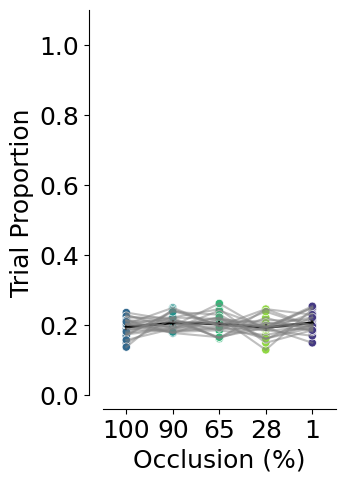

In [ ]:
fig,ax = plt.subplots(1,1, figsize = (3,5))
plotting.plot_trial_count(df=big_df, ax=ax, alpha=0.5, cmap=["#fde725", "#440154",  "#3b528b", "#21918c", "#5ec962"], per_aperture=True)
ax.set_xlabel("Occlusion (%)")
ax.set_ylabel("Trial Proportion")
ax.set_xticks([0,1,2,3,4], ["100", "90", "65", "28", "1"])
ax.set_ylim(0,1.1)
sns.despine(offset=10)
plt.savefig(save_fig_path + "multi_occluder_trial_number.svg", transparent=True)

2025-01-09 15:52:14,852::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-09 15:52:14,852::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-09 15:52:14,857::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-09 15:52:14,857::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-09 15:52:14,877::INFO::category.py::Using categorical un

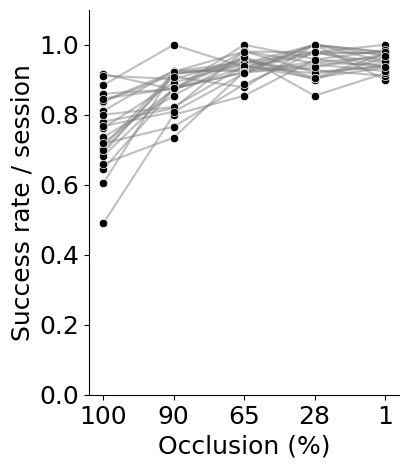

In [12]:
fig,ax = plt.subplots(1,1, figsize = (4,5))
rewards = big_df.groupby(["dataset", "aperture","trial"], as_index = False)["trial_rewarded"].mean(numeric_only=True)
rewards = rewards.groupby(["dataset", "aperture"], as_index=False).mean()

rewards ["aperture"] = rewards.aperture.astype(str)
sns.scatterplot(data=rewards, x ="aperture", y="trial_rewarded",color="black",zorder=100, ax=ax, legend=False)
sns.lineplot(data=rewards, x ="aperture", y="trial_rewarded", units="dataset", estimator=None, zorder=0, ax=ax, color="grey", alpha=0.5)
ax.set_xlabel("Occlusion (%)")
ax.set_ylabel("Success rate / session")
ax.set_xticks([0,1,2,3,4], ["100", "90", "65", "28", "1"])
ax.set_ylim(0,1.1)

plt.savefig(save_fig_path + "multi_occluder_rewards.svg", transparent=True)

2025-01-09 15:52:16,328::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-09 15:52:16,328::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-09 15:52:16,335::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-09 15:52:16,335::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-09 15:52:16,382::INFO::category.py::Using categorical un

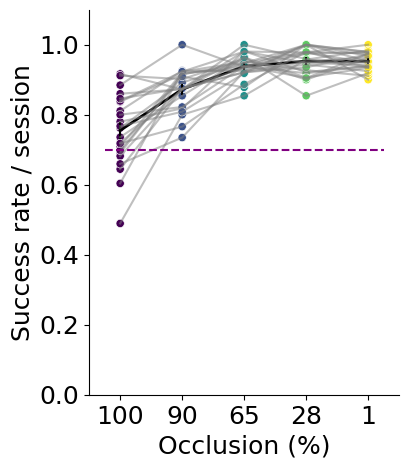

In [13]:
fig,ax = plt.subplots(1,1, figsize = (4,5))
plotting.plot_rewards(df=big_df, ax=ax, alpha=0.5, per_aperture=True,cmap=["#fde725", "#440154",  "#3b528b", "#21918c", "#5ec962"])
plt.ylim(0,1.1)
ax.set_xticks([0,1,2,3,4], ["100", "90", "65", "28", "1"])
ax.set_xlabel("Occlusion (%)")
ax.set_ylabel("Success rate / session")
ax.set_xticks([0,1,2,3,4], ["100", "90", "65", "28", "1"])
ax.set_ylim(0,1.1)
plt.savefig(save_fig_path + "multi_occluder_rewards.svg", transparent=True)

In [14]:
# Filter the data - no iti and only J_shaped trials
big_df = big_df [big_df.iti == 0.0].copy()
j_shaped =  analysis.get_jshaped_trials(big_df)
j_shaped = utils.create_bins(data=j_shaped.copy(), spatial_ybins=[6.75, 20, 30], label="y")

mean_mouse = j_shaped.groupby(
    ["dataset", "trial_left_choice", "aperture", "bin_centers"], as_index=False
).mean(numeric_only =True).copy()

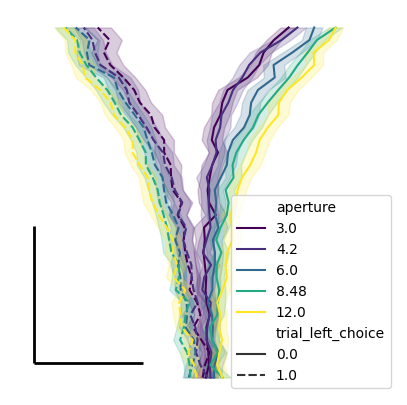

In [15]:
fig, ax = plt.subplots(1,1,figsize=(5,5))
plotting.lineplot_flip_axis(
    data=mean_mouse,
    x=mean_mouse.bin_centers,
    y="x",
    hue="trial_left_choice" if len(mean_mouse.aperture.unique()) == 2 else "aperture",
    palette=plotting.colors_choice if len(mean_mouse.aperture.unique()) == 2 else "viridis",
    style="aperture" if len(mean_mouse.aperture.unique()) == 2 else "trial_left_choice",
    errorbar="se",
    ax=ax,
)
plt.ylabel("y position")
plt.xlabel("x position")
plt.xlim(-16,16)
plt.vlines(x=-14, ymin=7.5, ymax=12.5, color="black", linewidth=2)
plt.hlines(y=7.5, xmin=-14, xmax=-5, color="black", linewidth=2)
plt.axis('off')
ax.legend(loc="lower right")
sns.despine(offset = 10)
plt.savefig(save_fig_path + "multi_occluder_mean_trajectories.svg", transparent=True)

In [16]:
j_shaped = utils.create_bins(data=j_shaped.copy(), spatial_ybins=[6.75, 20, 30], label="y")
j_shaped = j_shaped
j_shaped["flip_one_side"] = j_shaped["trial_left_choice"].replace([0, 1], [1, -1])
j_shaped ["x_flipped"] = j_shaped.x * j_shaped.flip_one_side
mean_mouse = j_shaped.groupby(
    ["dataset", "trial_left_choice", "aperture", "bin_centers", "trial"], as_index=False
).mean(numeric_only=True).copy()
mean_mouse = mean_mouse.groupby(
    ["dataset", "aperture", "bin_centers"], as_index=False
).mean(numeric_only=True).copy()

In [17]:
anova_rm = AnovaRM(mean_mouse, depvar='x_flipped', subject='dataset', within=['aperture', 'bin_centers'])
anova_results = anova_rm.fit()

# Print the ANOVA table
print(anova_results)

# If you want to save the results to a variable and explore it further
anova_table = anova_results.summary()

# Display the summary table
print(anova_table)

                         Anova
                     F Value   Num DF    Den DF  Pr > F
-------------------------------------------------------
aperture              23.4669   4.0000   88.0000 0.0000
bin_centers          196.5778  28.0000  616.0000 0.0000
aperture:bin_centers   7.4957 112.0000 2464.0000 0.0000

                         Anova
                     F Value   Num DF    Den DF  Pr > F
-------------------------------------------------------
aperture              23.4669   4.0000   88.0000 0.0000
bin_centers          196.5778  28.0000  616.0000 0.0000
aperture:bin_centers   7.4957 112.0000 2464.0000 0.0000



<Axes: xlabel='bin_centers', ylabel='x_flipped'>

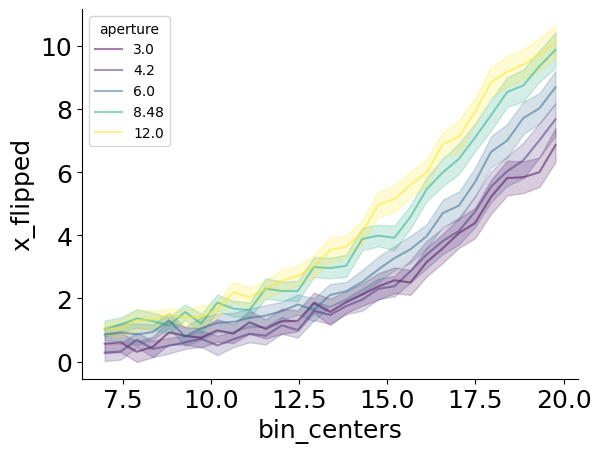

In [18]:
sns.lineplot(data=mean_mouse, x = "bin_centers", y = "x_flipped", hue="aperture", palette="viridis", errorbar="se", alpha=0.5)


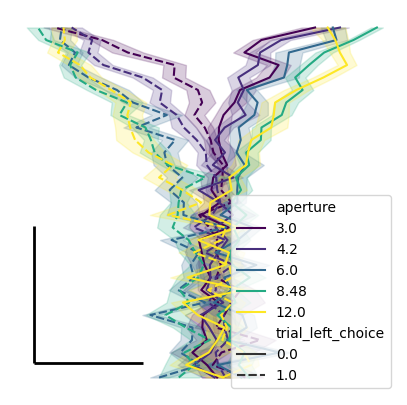

In [19]:
fig, ax = plt.subplots(1,1,figsize=(5,5))
plotting.lineplot_flip_axis(
    data=j_shaped [j_shaped.dataset ==  "Kiwi_2024-08-19_1"],
    x="bin_centers",
    y="x",
    hue="trial_left_choice" if len(mean_mouse.aperture.unique()) == 2 else "aperture",
    palette=plotting.colors_choice[::-1] if len(mean_mouse.aperture.unique()) == 2 else "viridis",
    style="aperture" if len(mean_mouse.aperture.unique()) == 2 else "trial_left_choice",
    errorbar="se",
    ax=ax,
)
plt.ylabel("y position")
plt.xlabel("x position")
plt.xlim(-16,16)
plt.vlines(x=-14, ymin=7.5, ymax=12.5, color="black", linewidth=2)

plt.hlines(y=7.5, xmin=-14, xmax=-5, color="black", linewidth=2)
#plt.arrow(-14, 7.5, 10, 0, head_width=.3, head_length=.5, linewidth=2, color='black', length_includes_head=True)
plt.axis('off')

ax.legend(loc="lower right")
plt.savefig(save_fig_path + "multi_occluder_trajectories_example_session.svg", transparent=True)